In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import sklearn.metrics as metrics
import seaborn as sns
%matplotlib inline

In [2]:
# Read the remote directly from its url (Jupyter):
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# Assign colum names to the dataset
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']
# Read dataset to pandas dataframe
dataset = pd.read_csv(url, names=names)

In [3]:
dataset.tail()

,sepal-length,sepal-width,petal-length,petal-width,Class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [4]:
dataset.describe()

,sepal-length,sepal-width,petal-length,petal-width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#This means that out of total 150 records:
#the training set will contain 120 records & 
#the test set contains 30 of those records.

In [7]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [8]:
y_pred = classifier.predict(X_test)

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[13  0  0]
 [ 0 11  0]
 [ 0  0  6]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      1.00      1.00        11
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Text(0.5, 23.52222222222222, 'Actual label')

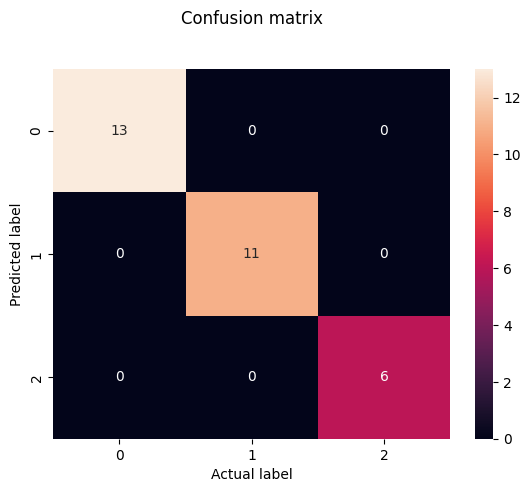

In [10]:
cm = pd.DataFrame(confusion_matrix(y_test, y_pred))
sns.heatmap(cm, annot=True)
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label')

In [11]:
error = []

# Calculating error for K values between 1 and 50
# In each iteration the mean error for predicted values of test set is calculated and
# the result is appended to the error list.
for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Mean Error')

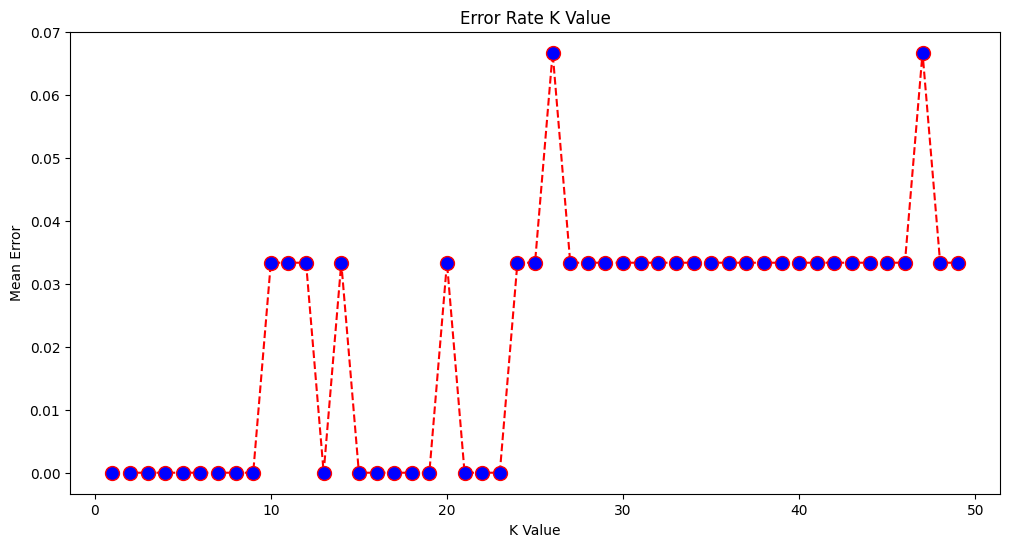

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 50), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

Estimated qb_kg_m_s: 7.17661


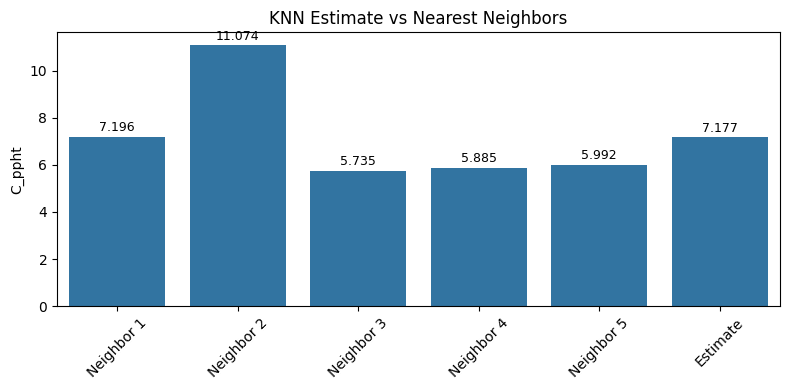

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load Database ---
filename = "solids_in_rivers.csv"
df = pd.read_csv(filename)

# --- Step 2: Read Input File (6 lines) ---
with open("input.dat", "r") as f:
    lines = [float(line.strip()) for line in f.readlines()]

mySlope, myD50, myQ, myW, nxp, near = lines
near = int(near)
nxp = float(nxp)

# --- Step 3: Compute z-scores for DB ---
feature_names = ["S_m_m", "D50_m", "Q_m3_s", "U_m_s"]
features_z = {}

for feat in feature_names:
    mu = df[feat].mean(skipna=True)
    sigma = df[feat].std(skipna=True)
    features_z[feat] = (df[feat] - mu) / sigma

# --- Step 4: Compute z-scores for inputs ---
myZ = {
    "S_m_m": (mySlope - df["S_m_m"].mean()) / df["S_m_m"].std(),
    "D50_m": (myD50 - df["D50_m"].mean()) / df["D50_m"].std(),
    "Q_m3_s": (myQ - df["Q_m3_s"].mean()) / df["Q_m3_s"].std(),
    "U_m_s": (myW - df["U_m_s"].mean()) / df["U_m_s"].std()
}

# --- Step 5: Compute distances ---
zdist = ((features_z["S_m_m"] - myZ["S_m_m"])**nxp +
         (features_z["D50_m"] - myZ["D50_m"])**nxp +
         (features_z["Q_m3_s"] - myZ["Q_m3_s"])**nxp +
         (features_z["U_m_s"] - myZ["U_m_s"])**nxp) ** (1.0 / nxp)

# --- Step 6: Sort and estimate ---
df["distance"] = zdist
#df_sorted = df.sort_values(by=["distance", "qb_kg_m_s"])
df_sorted = df.sort_values(by=["distance", "C_ppht"])
#nearest_qb = df_sorted["qb_kg_m_s"].iloc[:near]
nearest_qb = df_sorted["C_ppht"].iloc[:near]
estimate = nearest_qb.mean()

print(f"Estimated qb_kg_m_s: {estimate:.5f}")

# --- Step 7: Bar Chart of 5 Nearest Neighbors + Estimate ---
bar_vals = list(nearest_qb.iloc[:5].values) + [estimate]
bar_labels = [f"Neighbor {i+1}" for i in range(min(5, near))] + ["Estimate"]

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=bar_labels, y=bar_vals)
plt.ylabel("C_ppht")
plt.title("KNN Estimate vs Nearest Neighbors")

# Add value labels
for i, val in enumerate(bar_vals):
    ax.text(i, val + 0.01 * max(bar_vals), f"{val:.3f}", ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Mean Squared Error: 8689408.669
R² Score: -0.017

Estimated target for input: 0.054

5 Nearest Neighbors:
Neighbor 1:
  Distance: 0.728
  Target: 0.035
  Features: [1.89000e+01 1.29452e+00 1.09000e+00 1.46000e+01 1.19000e+00 1.02000e+00
 7.00000e-04 1.30000e-03 2.65000e+03 9.99728e+02]

Neighbor 2:
  Distance: 0.728
  Target: 0.116
  Features: [1.89000e+01 1.29452e+00 1.09000e+00 1.46000e+01 1.19000e+00 1.02000e+00
 7.00000e-04 1.30000e-03 2.65000e+03 9.99728e+02]

Neighbor 3:
  Distance: 0.735
  Target: 0.051
  Features: [1.88000e+01 1.28767e+00 1.08000e+00 1.46000e+01 1.18000e+00 1.02000e+00
 7.00000e-04 1.30000e-03 2.65000e+03 9.99728e+02]

Neighbor 4:
  Distance: 0.735
  Target: 0.044
  Features: [1.88000e+01 1.28767e+00 1.08000e+00 1.46000e+01 1.18000e+00 1.02000e+00
 7.00000e-04 1.30000e-03 2.65000e+03 9.99728e+02]

Neighbor 5:
  Distance: 0.794
  Target: 0.022
  Features: [1.92000e+01 1.31507e+00 1.19000e+00 1.46000e+01 1.17000e+00 1.01000e+00
 7.00000e-04 1.30000e-03 2.65000e+0

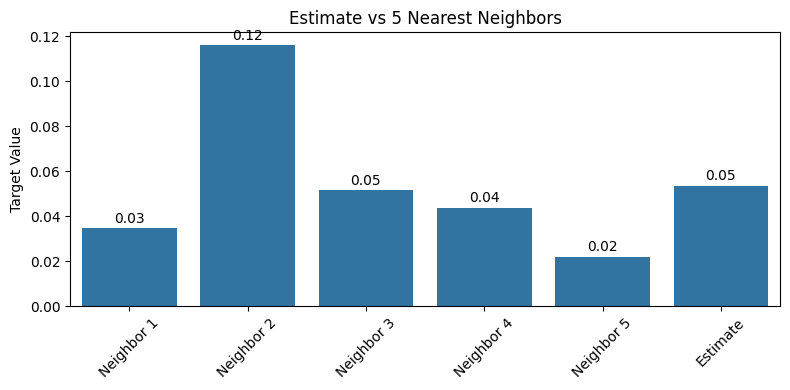

In [14]:
# Load needed libaries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sklearn.metrics as metrics
import seaborn as sns
%matplotlib inline

# Download data from remote source
# insert uget requests 
filename = "solids_in_rivers.csv"

# Load dataset
df = pd.read_csv(filename)
column_names = df.columns.tolist()
indices = list(range(3, 10)) + [11] + list(range(15, 17))
feature_set = [column_names[i] for i in indices]
#  build target set (1 of 2)
indices = list(range(17,18))
target_set_1 = [column_names[i] for i in indices]
# build target set (2 of 2)
indices = list(range(18,19))
target_set_2 = [column_names[i] for i in indices]
# Build design matrix and target vectors
X = df[feature_set] # Build X design matrix
y_one = df[target_set_1]
y_two = df[target_set_2]
# Concatenate into a single DataFrame to drop rows with NaNs in any relevant part
combined = pd.concat([X, y_one, y_two], axis=1)
combined = combined.dropna()
# Re-split into X, y_one, y_two
X_clean = combined[feature_set]
y_one_clean = combined[target_set_1]
y_two_clean = combined[target_set_2]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_two_clean, test_size=0.1) #Split dataframe for testing
from sklearn.neighbors import KNeighborsRegressor
regressor = KNeighborsRegressor(n_neighbors=5,p=2)
#regressor.fit(X_train, y_train)
regressor.fit(X_clean, y_one_clean)
# Predict on test set
y_pred = regressor.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

# --- Define an arbitrary input vector (must match feature_set structure) ---
# Example: A vector with same order and type as your training features
# Replace with real values or user input as needed
# Wrap input in a DataFrame with correct column names
# === Prompt for user input with default fallback ===
console_prompt = False # Set to True for live server demo, otherwise leave False or Sphinx build fails
default_input = [18.9,1.29452,1.09,14.6,1.19,1.02,0.0007,0.0013,2650,999]
values = default_input

if console_prompt:
    user_input = input(f"\nEnter {len(default_input)} feature values separated by commas\n[Press Enter to use default]: ")

    if user_input.strip():
        try:
            values = [float(x.strip()) for x in user_input.split(",")]
            if len(values) != len(default_input):
                raise ValueError("Incorrect number of features")
        except Exception as e:
            print(f"Invalid input. Using default. Reason: {e}")
            values = default_input
        else:
            values = default_input


new_input_df = pd.DataFrame([values], columns=feature_set)

# === Prediction and neighbor extraction ===
y_est = float(regressor.predict(new_input_df).item())
print(f"\nEstimated target for input: {y_est:.3f}")

distances, indices = regressor.kneighbors(new_input_df, n_neighbors=5, return_distance=True)
neighbor_features = X_clean.iloc[indices[0]]
neighbor_targets = y_one_clean.iloc[indices[0]]

# === Print neighbor data ===
print("\n5 Nearest Neighbors:")
for i in range(5):
    neighbor_target = float(neighbor_targets.iloc[i, 0])
    print(f"Neighbor {i+1}:")
    print(f"  Distance: {distances[0][i]:.3f}")
    print(f"  Target: {neighbor_target:.3f}")
    print(f"  Features: {neighbor_features.iloc[i].values}\n")

# === Plot bar chart with labels ===
labels = [f'Neighbor {i+1}' for i in range(5)] + ['Estimate']
values = list(neighbor_targets.iloc[:, 0].values) + [y_est]

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=labels, y=values)
plt.ylabel("Target Value")
plt.title("Estimate vs 5 Nearest Neighbors")

# Add text labels on bars
for i, val in enumerate(values):
    ax.text(i, val + 0.01 * max(values), f"{val:.2f}", ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
# Feature Permutation Importance examination
from sklearn.inspection import permutation_importance

result = permutation_importance(regressor, X_test, y_test, n_repeats=10, random_state=42)

# Display ranked importances
importances = result.importances_mean
sorted_idx = np.argsort(importances)[::-1]

for i in sorted_idx:
    print(f"{X_test.columns[i]}: {importances[i]:.4f}")

Rhos_kg_m3: 0.0012
U_m_s: 0.0011
W_m: 0.0006
Q_m3_s: 0.0003
Rho_kg_m3: 0.0002
S_m_m: 0.0002
q_m2_s: 0.0001
H_m: 0.0001
R_m: 0.0000
D50_m: -0.0000


In [16]:
# Autobuild the exercise set for this section.
import subprocess

try:
    subprocess.run(["pdflatex", "ce5319-es8-2025-2.tex"], 
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
except subprocess.CalledProcessError:
    print("Build failed. Check your LaTeX source file.")